In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import keras
from keras import layers

# Charger le CSV Airline Passengers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
print(f"\nAperçu :")
print(df.head(10))
print(f"\nMin : {df['Passengers'].min()}, Max : {df['Passengers'].max()}")

Shape : (144, 2)
Colonnes : ['Month', 'Passengers']

Aperçu :
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
5  1949-06         135
6  1949-07         148
7  1949-08         148
8  1949-09         136
9  1949-10         119

Min : 104, Max : 622


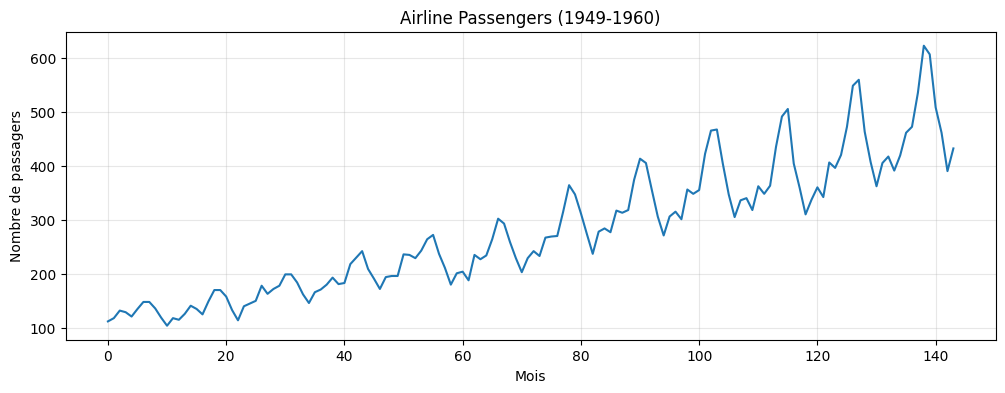

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(df['Passengers'].values)
plt.title("Airline Passengers (1949-1960)")
plt.xlabel("Mois")
plt.ylabel("Nombre de passagers")
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Extraire les valeurs et convertir en float32
data = df['Passengers'].values.astype('float32').reshape(-1, 1)

# Normaliser entre 0 et 1 (le LSTM est sensible aux grandes valeurs)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Split temporel 67/33
split = int(len(data_scaled) * 0.67)
train = data_scaled[:split]
test = data_scaled[split:]

print(f"Data scaled — min : {data_scaled.min():.2f}, max : {data_scaled.max():.2f}")
print(f"Train : {train.shape[0]} points")
print(f"Test  : {test.shape[0]} points")
print(f"Split à l'index {split} (mois {df['Month'].iloc[split]})")

Data scaled — min : 0.00, max : 1.00
Train : 96 points
Test  : 48 points
Split à l'index 96 (mois 1957-01)


In [5]:
def create_dataset(dataset, window_size=12):
    """
    Transforme une série 1D en paires (X, y) via sliding window.
    Retourne X : (N - window_size, window_size, 1), y : (N - window_size,)
    """
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:i + window_size, 0])
        y.append(dataset[i + window_size, 0])
    X = np.array(X).reshape(-1, window_size, 1)
    y = np.array(y)
    return X, y

WINDOW_SIZE = 12

X_train, y_train = create_dataset(train, WINDOW_SIZE)
X_test, y_test = create_dataset(test, WINDOW_SIZE)

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (84, 12, 1)
y_train : (84,)
X_test  : (36, 12, 1)
y_test  : (36,)


In [6]:
# Happy path : vérification des shapes et normalisation
assert X_train.shape == (84, 12, 1), f"Shape X_train incorrecte : {X_train.shape}"
assert y_train.shape == (84,), f"Shape y_train incorrecte : {y_train.shape}"
assert data_scaled.min() >= 0 and data_scaled.max() <= 1, "Normalisation hors [0,1]"
print("✅ Happy path OK : shapes correctes, normalisation [0,1]")

# Edge case : window_size=1
X_edge, y_edge = create_dataset(train, window_size=1)
print(f"\n🔍 Edge case window=1 : X={X_edge.shape}, y={y_edge.shape}")
print(f"   Avec 1 seul step de contexte, le modèle ne peut que copier la valeur précédente")

# Adversarial : NaN dans le dataset
data_nan = train.copy()
data_nan[5, 0] = np.nan
X_nan, y_nan = create_dataset(data_nan, WINDOW_SIZE)
has_nan = np.isnan(X_nan).any() or np.isnan(y_nan).any()
print(f"\n⚠️  Adversarial NaN : présence de NaN dans le dataset = {has_nan}")
print(f"   Protection possible : ajouter un assert not np.isnan(dataset).any() en début de create_dataset")

✅ Happy path OK : shapes correctes, normalisation [0,1]

🔍 Edge case window=1 : X=(95, 1, 1), y=(95,)
   Avec 1 seul step de contexte, le modèle ne peut que copier la valeur précédente

⚠️  Adversarial NaN : présence de NaN dans le dataset = True
   Protection possible : ajouter un assert not np.isnan(dataset).any() en début de create_dataset


In [7]:
model = keras.Sequential([
    layers.LSTM(64, input_shape=(WINDOW_SIZE, 1)),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0231 - mae: 0.1182 - val_loss: 0.0200 - val_mae: 0.1142
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0078 - mae: 0.0767 - val_loss: 0.0149 - val_mae: 0.0997
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052 - mae: 0.0537 - val_loss: 0.0274 - val_mae: 0.1382
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - mae: 0.0537 - val_loss: 0.0147 - val_mae: 0.1009
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - mae: 0.0574 - val_loss: 0.0131 - val_mae: 0.0970
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0035 - mae: 0.0445 - val_loss: 0.0145 - val_mae: 0.1013
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041 - mae: 0.0499 - val_loss: 0.0118 - val_mae: 0.0918
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0038 - mae: 0.0476 - val_loss: 0.0122 - val_mae: 0.0938
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - lo

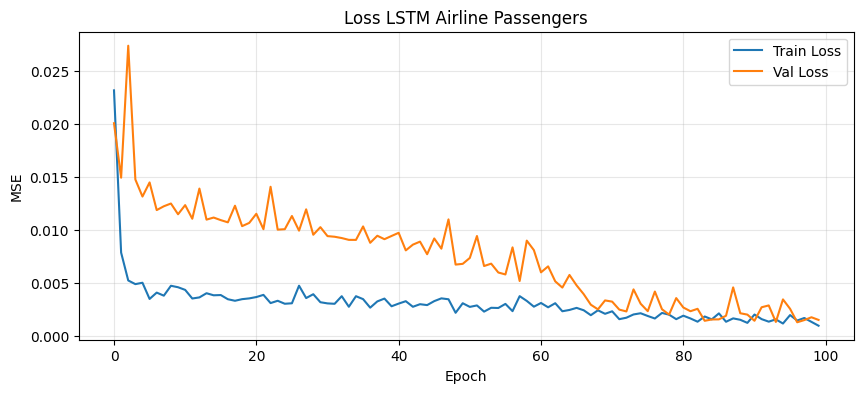

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss LSTM Airline Passengers")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error

# Prédictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Dénormaliser
train_pred_inv = scaler.inverse_transform(train_pred)
test_pred_inv = scaler.inverse_transform(test_pred)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# RMSE en unité passagers
rmse_train = np.sqrt(mean_squared_error(y_train_inv, train_pred_inv))
rmse_test = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))

print(f"RMSE Train : {rmse_train:.2f} passagers")
print(f"RMSE Test  : {rmse_test:.2f} passagers")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
RMSE Train : 16.65 passagers
RMSE Test  : 37.53 passagers


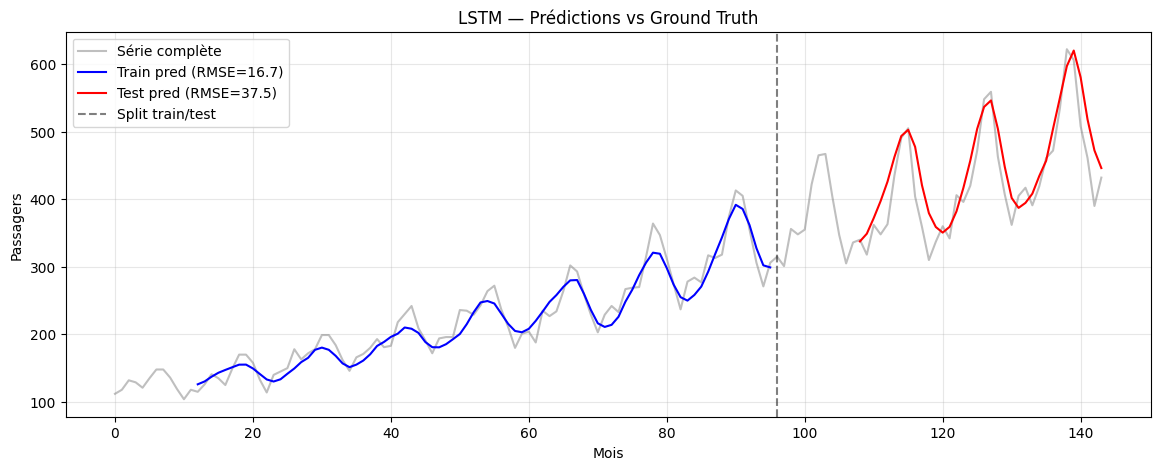

In [11]:
plt.figure(figsize=(14, 5))

# Série complète en gris
plt.plot(df['Passengers'].values, color='gray', alpha=0.5, label='Série complète')

# Prédictions train (décalées de WINDOW_SIZE car les 12 premiers mois servent d'input)
train_range = range(WINDOW_SIZE, WINDOW_SIZE + len(train_pred_inv))
plt.plot(train_range, train_pred_inv, color='blue', label=f'Train pred (RMSE={rmse_train:.1f})')

# Prédictions test
test_range = range(split + WINDOW_SIZE, split + WINDOW_SIZE + len(test_pred_inv))
plt.plot(test_range, test_pred_inv, color='red', label=f'Test pred (RMSE={rmse_test:.1f})')

plt.axvline(x=split, color='black', linestyle='--', alpha=0.5, label='Split train/test')
plt.title("LSTM — Prédictions vs Ground Truth")
plt.xlabel("Mois")
plt.ylabel("Passagers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
model.save('airline_lstm.keras')
print("✅ Modèle Airline LSTM sauvegardé : airline_lstm.keras")

print(f"\n📊 RMSE Test : {rmse_test:.2f} passagers")
if rmse_test < 50:
    print("✅ Happy path : RMSE < 50, excellent !")
elif rmse_test < 70:
    print("✅ Happy path : RMSE < 70, bon résultat")
else:
    print("⚠️  RMSE > 70, le modèle pourrait être amélioré")

print(f"📈 Epochs effectuées : {len(history.history['loss'])}")
print(f"📉 Val loss finale : {history.history['val_loss'][-1]:.6f}")

✅ Modèle Airline LSTM sauvegardé : airline_lstm.keras

📊 RMSE Test : 37.53 passagers
✅ Happy path : RMSE < 50, excellent !
📈 Epochs effectuées : 100
📉 Val loss finale : 0.001483


In [13]:
import time

def build_and_train(rnn_layer_class, units=64, epochs=50, label=''):
    """
    Construit et entraîne un modèle avec le layer RNN passé en paramètre.
    Retourne (modèle entraîné, historique, durée en secondes, RMSE test).
    """
    m = keras.Sequential([
        rnn_layer_class(units, input_shape=(WINDOW_SIZE, 1)),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])

    m.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    start = time.time()
    hist = m.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=8,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )
    duration = time.time() - start

    # RMSE test dénormalisé
    pred = m.predict(X_test, verbose=0)
    pred_inv = scaler.inverse_transform(pred)
    rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))

    real_epochs = len(hist.history['loss'])
    params = m.count_params()
    val_loss = hist.history['val_loss'][-1]

    print(f"\n{'='*40}")
    print(f"📊 {label} — Résultats")
    print(f"   RMSE test     : {rmse:.2f} passagers")
    print(f"   Params        : {params:,}")
    print(f"   Epochs réelles: {real_epochs}")
    print(f"   Durée totale  : {duration:.1f}s ({duration/real_epochs:.2f}s/epoch)")
    print(f"   Val loss finale: {val_loss:.6f}")
    print(f"{'='*40}")

    return m, hist, duration, rmse

In [14]:
lstm_model, lstm_history, lstm_time, lstm_rmse = build_and_train(
    layers.LSTM, units=64, epochs=50, label='LSTM'
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0219 - mae: 0.1168 - val_loss: 0.0183 - val_mae: 0.1068
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0074 - mae: 0.0715 - val_loss: 0.0152 - val_mae: 0.1008
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0053 - mae: 0.0558 - val_loss: 0.0288 - val_mae: 0.1423
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - mae: 0.0539 - val_loss: 0.0167 - val_mae: 0.1058
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - mae: 0.0568 - val_loss: 0.0141 - val_mae: 0.1004
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0050 - mae: 0.0537 - val_loss: 0.0166 - val_mae: 0.1068
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0045 - mae: 0.0519 - val_loss: 0.0120 - val_mae: 0.0922
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0039 - mae: 0.0478 - val_loss: 0.0135 - val_mae: 0.0994
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0039 - mae: 0.

In [15]:
gru_model, gru_history, gru_time, gru_rmse = build_and_train(
    layers.GRU, units=64, epochs=50, label='GRU'
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0362 - mae: 0.1502 - val_loss: 0.0552 - val_mae: 0.2164
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0087 - mae: 0.0768 - val_loss: 0.0180 - val_mae: 0.1081
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0081 - mae: 0.0742 - val_loss: 0.0302 - val_mae: 0.1475
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055 - mae: 0.0598 - val_loss: 0.0322 - val_mae: 0.1528
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0060 - mae: 0.0632 - val_loss: 0.0208 - val_mae: 0.1187
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - mae: 0.0557 - val_loss: 0.0171 - val_mae: 0.1089
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0042 - mae: 0.0506 - val_loss: 0.0166 - val_mae: 0.1078
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0046 - mae: 0.0513 - val_loss: 0.0158 - val_mae: 0.1052
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0037 - mae: 0.


📊 GRU — Résultats
   RMSE test     : 50.84 passagers
   Params        : 12,929
   Epochs réelles: 50
   Durée totale  : 10.2s (0.20s/epoch)
   Val loss finale: 0.004881


In [16]:
lstm_epochs = len(lstm_history.history['loss'])
gru_epochs = len(gru_history.history['loss'])

print("=" * 60)
print(f"{'Métrique':<25} {'LSTM':>15} {'GRU':>15}")
print("-" * 60)
print(f"{'RMSE test (passagers)':<25} {lstm_rmse:>15.2f} {gru_rmse:>15.2f}")
print(f"{'Training time total (s)':<25} {lstm_time:>15.1f} {gru_time:>15.1f}")
print(f"{'Durée par epoch (s)':<25} {lstm_time/lstm_epochs:>15.2f} {gru_time/gru_epochs:>15.2f}")
print(f"{'Nombre de paramètres':<25} {lstm_model.count_params():>15,} {gru_model.count_params():>15,}")
print(f"{'Val loss finale':<25} {lstm_history.history['val_loss'][-1]:>15.6f} {gru_history.history['val_loss'][-1]:>15.6f}")
print(f"{'Epochs réelles':<25} {lstm_epochs:>15} {gru_epochs:>15}")
print("=" * 60)

Métrique                             LSTM             GRU
------------------------------------------------------------
RMSE test (passagers)               55.24           50.84
Training time total (s)               9.5            10.2
Durée par epoch (s)                  0.19            0.20
Nombre de paramètres               16,961          12,929
Val loss finale                  0.006560        0.004881
Epochs réelles                         50              50


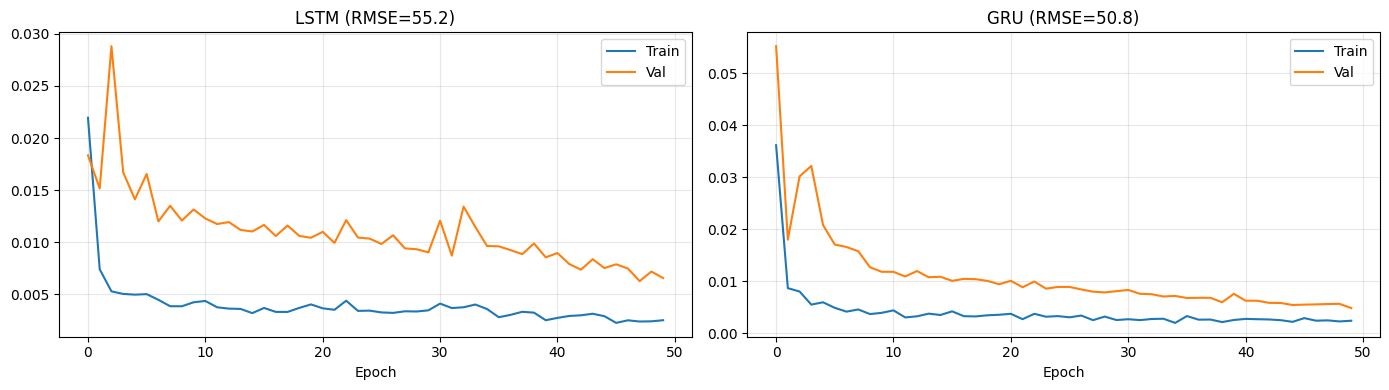

✅ Modèle GRU sauvegardé : airline_gru.keras


In [18]:
# Courbes de loss comparées
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_history.history['loss'], label='Train')
axes[0].plot(lstm_history.history['val_loss'], label='Val')
axes[0].set_title(f"LSTM (RMSE={lstm_rmse:.1f})")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(gru_history.history['loss'], label='Train')
axes[1].plot(gru_history.history['val_loss'], label='Val')
axes[1].set_title(f"GRU (RMSE={gru_rmse:.1f})")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Sauvegarde du modèle GRU
gru_model.save('airline_gru.keras')
print("✅ Modèle GRU sauvegardé : airline_gru.keras")

In [19]:
# Happy path : GRU a moins de paramètres que LSTM
assert gru_model.count_params() < lstm_model.count_params(), "GRU devrait avoir moins de params"
print("✅ Happy path : GRU a bien moins de paramètres que LSTM")
print(f"   LSTM : {lstm_model.count_params():,} vs GRU : {gru_model.count_params():,}")

# Différence de RMSE
diff = abs(lstm_rmse - gru_rmse)
print(f"\n📊 Différence de RMSE : {diff:.2f} passagers")
if diff < 10:
    print("   → Écart faible, cohérent pour un petit dataset")
else:
    print("   → Écart notable, probablement dû au seed aléatoire")

✅ Happy path : GRU a bien moins de paramètres que LSTM
   LSTM : 16,961 vs GRU : 12,929

📊 Différence de RMSE : 4.40 passagers
   → Écart faible, cohérent pour un petit dataset


In [20]:
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBED_DIM = 128

# Charger IMDB (déjà tokenisé en indices)
(X_train_raw, y_train_imdb), (X_test_raw, y_test_imdb) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Train : {len(X_train_raw)} reviews")
print(f"Test  : {len(X_test_raw)} reviews")

# Stats sur la longueur des séquences
lengths = [len(x) for x in X_train_raw]
print(f"\nLongueur des reviews :")
print(f"  Min  : {min(lengths)}")
print(f"  Max  : {max(lengths)}")
print(f"  Mean : {np.mean(lengths):.0f}")
print(f"  Median : {np.median(lengths):.0f}")

print(f"\nDistribution labels : {np.bincount(y_train_imdb)} (0=négatif, 1=positif)")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train : 25000 reviews
Test  : 25000 reviews

Longueur des reviews :
  Min  : 11
  Max  : 2494
  Mean : 239
  Median : 178

Distribution labels : [12500 12500] (0=négatif, 1=positif)


In [21]:
# Padding PRE : les zéros sont au début, le signal utile est près de la fin
# → le LSTM voit le contenu réel en dernier, meilleur pour le hidden state final
X_train_pad = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test_pad = pad_sequences(X_test_raw, maxlen=MAX_LEN, padding='pre', truncating='pre')

print(f"X_train_pad : {X_train_pad.shape}")
print(f"X_test_pad  : {X_test_pad.shape}")
print(f"\nExemple review paddée (premiers tokens) : {X_train_pad[0][:20]}")

X_train_pad : (25000, 200)
X_test_pad  : (25000, 200)

Exemple review paddée (premiers tokens) : [  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112
 167   2]


In [22]:
# Récupérer le dictionnaire mot -> index
word_index = imdb.get_word_index()

# Inverser : index -> mot (les indices IMDB sont décalés de +3)
reverse_word_index = {v + 3: k for k, v in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<OOV>'
reverse_word_index[3] = '<UNUSED>'

# Décoder la première review
decoded = ' '.join([reverse_word_index.get(i, '?') for i in X_train_raw[0]])
print(f"Label : {'Positif' if y_train_imdb[0] else 'Négatif'}")
print(f"\nReview décodée :\n{decoded[:500]}...")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Label : Positif

Review décodée :
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <OOV> is an amazing actor and now the same being director <OOV> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <OOV> and would re...


In [23]:
# Test de l'Embedding : vérifier la transformation de shape
test_model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN)
])
test_model.build(input_shape=(None, MAX_LEN))
test_model.summary()

# Attendu : output shape = (None, 200, 128)
# Chaque token (indice entier) est transformé en vecteur dense de 128 dimensions
print(f"\n✅ Embedding transforme (batch, {MAX_LEN}) → (batch, {MAX_LEN}, {EMBED_DIM})")
print(f"   Paramètres Embedding : {VOCAB_SIZE} × {EMBED_DIM} = {VOCAB_SIZE * EMBED_DIM:,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 1,280,000 (4.88 MB)

 Non-trainable params: 0 (0.00 B)


✅ Embedding transforme (batch, 200) → (batch, 200, 128)
   Paramètres Embedding : 10000 × 128 = 1,280,000


In [24]:
# Happy path : shapes correctes
assert X_train_pad.shape == (25000, 200), f"Shape incorrecte : {X_train_pad.shape}"
assert X_test_pad.shape == (25000, 200), f"Shape incorrecte : {X_test_pad.shape}"
print("✅ Happy path : shapes (25000, 200) correctes")

# Edge case : token OOV (index 2)
oov_count = np.sum(X_train_pad == 2)
total_tokens = np.sum(X_train_pad > 0)
print(f"\n🔍 Edge case OOV : {oov_count} tokens OOV sur {total_tokens} tokens non-padding")
print(f"   Soit {oov_count/total_tokens*100:.1f}% de tokens hors vocabulaire")

# Adversarial : review très courte après padding
short_reviews = [i for i, x in enumerate(X_train_raw) if len(x) < 10]
print(f"\n⚠️  Adversarial : {len(short_reviews)} reviews de moins de 10 tokens")
if short_reviews:
    idx = short_reviews[0]
    pad_count = np.sum(X_train_pad[idx] == 0)
    print(f"   Review {idx} : {len(X_train_raw[idx])} tokens réels, {pad_count} tokens de padding")
    print(f"   → Avec padding='pre', le signal est en fin de séquence (mieux pour le LSTM)")

✅ Happy path : shapes (25000, 200) correctes

🔍 Edge case OOV : 214834 tokens OOV sur 4026931 tokens non-padding
   Soit 5.3% de tokens hors vocabulaire

⚠️  Adversarial : 0 reviews de moins de 10 tokens


In [26]:
from sklearn.metrics import f1_score, classification_report

model_imdb = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_imdb.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_imdb.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
early_stop_imdb = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

history_imdb = model_imdb.fit(
    X_train_pad, y_train_imdb,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop_imdb],
    verbose=1
)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7733 - loss: 0.4664 - val_accuracy: 0.8516 - val_loss: 0.3495
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8988 - loss: 0.2666 - val_accuracy: 0.8664 - val_loss: 0.3074
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9296 - loss: 0.1927 - val_accuracy: 0.8656 - val_loss: 0.3376
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9400 - loss: 0.1650 - val_accuracy: 0.8628 - val_loss: 0.3384
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9558 - loss: 0.1262 - val_accuracy: 0.8640 - val_loss: 0.3527


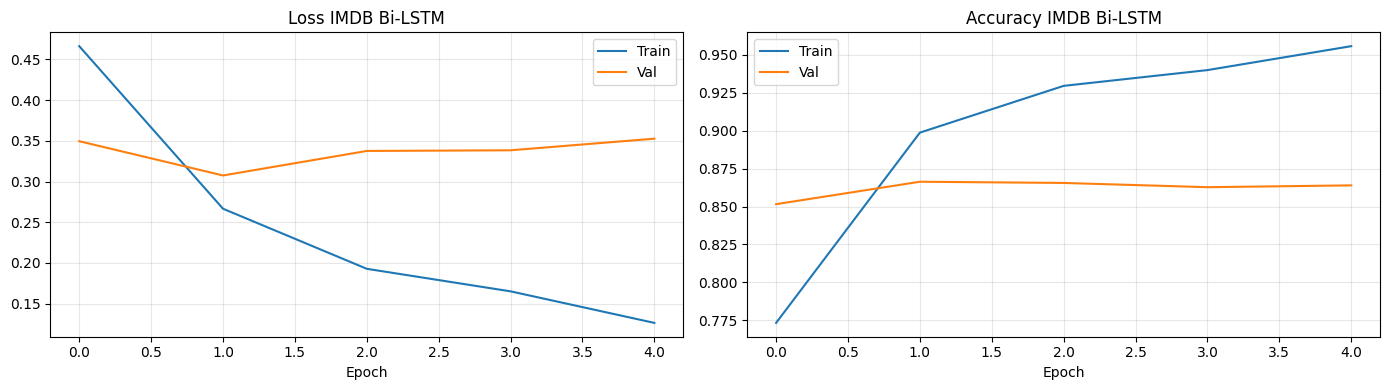

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_imdb.history['loss'], label='Train')
axes[0].plot(history_imdb.history['val_loss'], label='Val')
axes[0].set_title("Loss IMDB Bi-LSTM")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_imdb.history['accuracy'], label='Train')
axes[1].plot(history_imdb.history['val_accuracy'], label='Val')
axes[1].set_title("Accuracy IMDB Bi-LSTM")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Accuracy sur le test set
loss_test, acc_test = model_imdb.evaluate(X_test_pad, y_test_imdb, verbose=0)
print(f"Accuracy test : {acc_test:.4f}")

# Prédictions binarisées
y_pred_proba = model_imdb.predict(X_test_pad, verbose=0)
y_pred = (y_pred_proba > 0.5).astype('int32').flatten()

# F1-score
f1 = f1_score(y_test_imdb, y_pred)
print(f"F1-score test : {f1:.4f}")

print("\nRapport de classification :")
print(classification_report(y_test_imdb, y_pred, target_names=['Négatif', 'Positif']))

Accuracy test : 0.8697
F1-score test : 0.8679

Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.86      0.88      0.87     12500
     Positif       0.88      0.86      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



In [30]:
def predict_sentiment(text, model, word_index, max_len=MAX_LEN, vocab_size=VOCAB_SIZE):
    """Tokenize un texte brut et prédit le sentiment."""
    # Tokenisation manuelle (indices IMDB décalés de +3)
    tokens = text.lower().split()
    sequence = [word_index.get(w, 2) + 3 for w in tokens]  # 2 = OOV
    # Filtrer les tokens hors vocabulaire
    sequence = [idx if idx < vocab_size else 2 for idx in sequence]
    # Padding
    padded = pad_sequences([sequence], maxlen=max_len, padding='pre', truncating='pre')
    # Prédiction
    score = model.predict(padded, verbose=0)[0][0]
    label = "Positif" if score > 0.5 else "Négatif"
    print(f"📝 \"{text[:80]}...\"" if len(text) > 80 else f"📝 \"{text}\"")
    print(f"   → {label} (score : {score:.4f})\n")
    return score

# Tests
predict_sentiment("Absolutely terrible, boring beyond belief, waste of time", model_imdb, word_index)
predict_sentiment("Amazing movie, loved every minute of it, brilliant acting", model_imdb, word_index)
predict_sentiment("Really great movie... For falling asleep", model_imdb, word_index)
predict_sentiment("A masterpiece of boredom, I recommend it to anyone who wants to suffer", model_imdb, word_index)

📝 "Absolutely terrible, boring beyond belief, waste of time"
   → Négatif (score : 0.0534)

📝 "Amazing movie, loved every minute of it, brilliant acting"
   → Positif (score : 0.8991)

📝 "Really great movie... For falling asleep"
   → Positif (score : 0.6326)

📝 "A masterpiece of boredom, I recommend it to anyone who wants to suffer"
   → Positif (score : 0.8565)



np.float32(0.856508)

In [31]:
model_imdb.save('imdb_sentiment.keras')
print("✅ Modèle IMDB sauvegardé : imdb_sentiment.keras")

print(f"\n📊 Accuracy test : {acc_test:.4f}")
print(f"📊 F1-score test : {f1:.4f}")

if acc_test > 0.85:
    print("✅ Happy path : accuracy > 85%")
else:
    print("⚠️  Accuracy < 85%, le modèle pourrait être amélioré")

if f1 > 0.85:
    print("✅ Happy path : F1 > 0.85")
else:
    print("⚠️  F1 < 0.85")

✅ Modèle IMDB sauvegardé : imdb_sentiment.keras

📊 Accuracy test : 0.8697
📊 F1-score test : 0.8679
✅ Happy path : accuracy > 85%
✅ Happy path : F1 > 0.85


In [33]:
!pip install datasets -q

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer

# Chargement via HuggingFace
dataset = load_dataset('ag_news')

print(dataset)
print(f"\nExemple : {dataset['train'][0]}")

# Extraire textes et labels
train_texts = dataset['train']['text']
train_labels = np.array(dataset['train']['label'])
test_texts = dataset['test']['text']
test_labels = np.array(dataset['test']['label'])

label_names = ['World', 'Sports', 'Business', 'Sci/Tech']
print(f"\nClasses : {label_names}")
print(f"Distribution train : {np.bincount(train_labels)}")
print(f"Distribution test  : {np.bincount(test_labels)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Exemple : {'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}

Classes : ['World', 'Sports', 'Business', 'Sci/Tech']
Distribution train : [30000 30000 30000 30000]
Distribution test  : [1900 1900 1900 1900]


In [34]:
VOCAB_SIZE_AG = 20000
MAX_LEN_AG = 50
EMBED_DIM_AG = 64

# Tokenizer Keras : on construit le vocab à partir du corpus train
tokenizer_ag = Tokenizer(num_words=VOCAB_SIZE_AG, oov_token='<OOV>')
tokenizer_ag.fit_on_texts(train_texts)  # NE PAS fit sur test : data leakage

# Transformer en séquences paddées
X_train_ag = pad_sequences(tokenizer_ag.texts_to_sequences(train_texts), maxlen=MAX_LEN_AG, padding='pre', truncating='pre')
X_test_ag = pad_sequences(tokenizer_ag.texts_to_sequences(test_texts), maxlen=MAX_LEN_AG, padding='pre', truncating='pre')

print(f"X_train_ag : {X_train_ag.shape}")
print(f"X_test_ag  : {X_test_ag.shape}")
print(f"Vocab size réel : {len(tokenizer_ag.word_index):,} mots (on garde les top {VOCAB_SIZE_AG})")

X_train_ag : (120000, 50)
X_test_ag  : (7600, 50)
Vocab size réel : 70,345 mots (on garde les top 20000)


In [35]:
model_ag = keras.Sequential([
    layers.Embedding(VOCAB_SIZE_AG, EMBED_DIM_AG, input_length=MAX_LEN_AG),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

# Labels entiers 0/1/2/3 → sparse_categorical_crossentropy (pas besoin de one-hot)
model_ag.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_ag.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
history_ag = model_ag.fit(
    X_train_ag, train_labels,
    epochs=3,
    batch_size=256,
    validation_split=0.05,
    verbose=1
)

Epoch 1/3
446/446 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8398 - loss: 0.4553 - val_accuracy: 0.9123 - val_loss: 0.2634
Epoch 2/3
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9320 - loss: 0.2158 - val_accuracy: 0.9118 - val_loss: 0.2625
Epoch 3/3
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9436 - loss: 0.1746 - val_accuracy: 0.9095 - val_loss: 0.2673


In [37]:
loss_ag, acc_ag = model_ag.evaluate(X_test_ag, test_labels, verbose=0)
print(f"Accuracy AG News test : {acc_ag:.4f}")

# Prédictions : extraire la classe avec argmax
y_pred_ag = np.argmax(model_ag.predict(X_test_ag, verbose=0), axis=1)

print("\nRapport de classification :")
print(classification_report(
    test_labels, y_pred_ag,
    target_names=label_names
))

Accuracy AG News test : 0.9132

Rapport de classification :
              precision    recall  f1-score   support

       World       0.93      0.90      0.91      1900
      Sports       0.96      0.97      0.97      1900
    Business       0.88      0.88      0.88      1900
    Sci/Tech       0.88      0.90      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



In [38]:
def predict_ag_news(text, tokenizer, model, max_len, labels):
    """Tokenize un titre et affiche les probabilités par classe."""
    seq = pad_sequences(tokenizer.texts_to_sequences([text]), maxlen=max_len, padding='pre', truncating='pre')
    proba = model.predict(seq, verbose=0)[0]
    pred_class = labels[np.argmax(proba)]
    print(f"📰 \"{text}\"")
    for i, label in enumerate(labels):
        bar = "█" * int(proba[i] * 30)
        print(f"   {label:<10} : {proba[i]:.3f} {bar}")
    print(f"   → Prédiction : {pred_class}\n")

# Tests avec des titres ambigus
predict_ag_news("Tesla announces record quarterly profits", tokenizer_ag, model_ag, MAX_LEN_AG, label_names)
predict_ag_news("Olympics 2024: Tech companies sponsor all major sports events", tokenizer_ag, model_ag, MAX_LEN_AG, label_names)
predict_ag_news("NASA launches new satellite to study climate change", tokenizer_ag, model_ag, MAX_LEN_AG, label_names)
predict_ag_news("Stock market crashes after Federal Reserve raises interest rates", tokenizer_ag, model_ag, MAX_LEN_AG, label_names)

print("=" * 40)
if acc_ag > 0.85:
    print(f"✅ Happy path : accuracy {acc_ag:.4f} > 85%")
else:
    print(f"⚠️  Accuracy {acc_ag:.4f} < 85%")

print(f"📊 4 classes dans le rapport : {label_names}")

📰 "Tesla announces record quarterly profits"
   World      : 0.084 ██
   Sports     : 0.011 
   Business   : 0.516 ███████████████
   Sci/Tech   : 0.389 ███████████
   → Prédiction : Business

📰 "Olympics 2024: Tech companies sponsor all major sports events"
   World      : 0.103 ███
   Sports     : 0.403 ████████████
   Business   : 0.171 █████
   Sci/Tech   : 0.323 █████████
   → Prédiction : Sports

📰 "NASA launches new satellite to study climate change"
   World      : 0.009 
   Sports     : 0.002 
   Business   : 0.013 
   Sci/Tech   : 0.976 █████████████████████████████
   → Prédiction : Sci/Tech

📰 "Stock market crashes after Federal Reserve raises interest rates"
   World      : 0.043 █
   Sports     : 0.002 
   Business   : 0.916 ███████████████████████████
   Sci/Tech   : 0.039 █
   → Prédiction : Business

✅ Happy path : accuracy 0.9132 > 85%
📊 4 classes dans le rapport : ['World', 'Sports', 'Business', 'Sci/Tech']
